# Título: Aproximação de Soluções de Problemas de Programação Linear com Redes Neurais

## Resumo

Este notebook investiga a viabilidade de usar uma rede neural para aproximar a solução ótima de problemas de Programação Linear (PL) pequenos. Diferentemente dos métodos exatos, como o Simplex, que garantem a otimalidade a um custo computacional por instância, a rede neural atua como um solucionador rápido para o problema. O modelo é treinado em dados sintéticos, com as soluções ótimas fornecidas pela biblioteca PuLP. Ao final do estudo, os resultados mostram que a diferença entre os resultados obtidos via rede neural e via otimizador são estatísticamente igual.


## 1. Introdução

Os problemas de programação linear buscam otimizar uma função objetivo linear sujeita a um conjunto de restrições também lineares.

Métodos tradicionais, como o Simplex ou os métodos de pontos interiores, são capazes de encontrar soluções exatas com garantias formais. Neste projeto, investigamos uma abordagem diferente, que usa uma rede neural para encontrar soluções aproximadas.

Para isso, o trabalho segue três passos: primeiro, geramos uma grande quantidade de problemas de programação linear sintéticos. Em seguida, resolvemos cada um desses problemas com um solucionador exato (PuLP/CBC) para obter as respostas corretas. Por fim, usamos essas respostas para treinar uma rede neural a prever a solução de um problema com base apenas em seus coeficientes.

A ideia central desse trabalho é que, uma vez treinada a rede neural, ela possa
fornecer soluções de forma muito mais rápida, o que seria útil em situações onde é preciso responder a muitas solicitações em pouco tempo.



## 2. Formulação Matemática do Problema

**Primal (P):**
\begin{align}
\max_{x \in \mathbb{R}^2} \quad & c^\top x = c_1 x_1 + c_2 x_2 \\
\text{Sujeito às restrições:} \quad & a_{11} x_1 + a_{12} x_2 \le b_1, \\
& a_{21} x_1 + a_{22} x_2 \le b_2, \\
& x_1 \ge 0,\; x_2 \ge 0.
\end{align}

Escrevendo em forma matricial, $ \max \{ c^\top x \;|\; A x \le b,\; x \ge 0 \} $ com
$ A \in \mathbb{R}^{2 \times 2} , x \in \mathbb{R}^2, b \in \mathbb{R}^2, c \in \mathbb{R}^2$.

**Dual (D):**
\begin{align}
\min_{y \in \mathbb{R}^2} \quad & b^\top y = b_1 y_1 + b_2 y_2 \\
\text{Sujeito às restrições:} \quad & A^\top y \ge c, \;\; y \ge 0.
\end{align}


### 3. Obtenção e Preparação dos Dados

Os dados para o treinamento da rede neural foram gerados sinteticamente para simular uma variedade de problemas de Programação Linear. Cada problema $i$ foi definido por um conjunto de coeficientes e limites, formando um vetor de entrada $\mathbf{x}_{\text{in}}^{(i)}$. A solução ótima correspondente, $\mathbf{x}_{\text{out}}^{(i)}$, foi determinada usando um resolvedor exato de PL, a biblioteca **PuLP** com o solver **CBC**.

#### Geração de Dados

Para cada uma das $N$ amostras, os coeficientes e limites foram amostrados de distribuições uniformes dentro de intervalos específicos:

* Coeficientes da função objetivo: $c_1, c_2 \sim \mathcal{U}(0, 10)$
* Coeficientes das restrições: $a_1, a_2, a_3, a_4 \sim \mathcal{U}(0, 10)$
* Limites das restrições: $b_1, b_2 \sim \mathcal{U}(0, 20)$

O vetor de entrada para a rede neural é dado por:
$$\mathbf{x}_{\text{in}}^{(i)} = [c_1^{(i)}, c_2^{(i)}, a_1^{(i)}, a_2^{(i)}, a_3^{(i)}, a_4^{(i)}, b_1^{(i)}, b_2^{(i)}]$$

#### Resolução e Rótulos

A solução ótima para cada problema $i$ foi obtida resolvendo o seguinte problema de otimização:
$$
\begin{align*}
\max \quad & c_1^{(i)}x_1 + c_2^{(i)}x_2 \\
\text{s.t.} \quad & a_1^{(i)}x_1 + a_2^{(i)}x_2 \leq b_1^{(i)} \\
& a_3^{(i)}x_1 + a_4^{(i)}x_2 \leq b_2^{(i)} \\
& x_1, x_2 \geq 0
\end{align*}
$$

A solução ótima exata $[x_1^*, x_2^*]$ fornecida pelo PuLP serviu como o rótulo para o treinamento:
$$\mathbf{x}_{\text{out}}^{(i)} = [x_1^{*(i)}, x_2^{*(i)}]$$

Esses pares $(\mathbf{x}_{\text{in}}^{(i)}, \mathbf{x}_{\text{out}}^{(i)})$ formaram o conjunto de dados de treinamento, permitindo que a rede neural aprendesse a função de mapeamento da entrada para a saída.

# 3. Metodologia

A abordagem para o projeto foi dividida nas seguintes etapas:

### Parte 1: Geração de Dados e Resolução

Geramos $N=5000$ problemas aleatórios de PL. Para cada problema, os coeficientes $c_i$, $a_i$ e $b_i$ foram sorteados de distribuições uniformes. A solução ótima de cada problema foi obtida usando o PuLP.

### Parte 2: Treinamento da Rede Neural

Uma rede neural do tipo MLP (Perceptron Multicamadas) foi construída em PyTorch.

   - Arquitetura: A rede tem uma arquitetura de 8 (entrada) to 32 (oculta) to 16 (oculta) to 2 (saída).

   - Função de Ativação: ReLU (Rectified Linear Unit) foi utilizada nas camadas ocultas.

   - Função de Perda: Erro Quadrático Médio (MSE) foi a métrica de perda.

   - Otimizador: Adam foi o otimizador usado para ajustar os pesos da rede, com uma taxa de aprendizado de 0.01.

   - Épocas de Treinamento: O modelo foi treinado por 9400 épocas.

### Parte 3: Avaliação e Análise Estatística

A avaliação do modelo vai além das métricas de erro padrão. Além do cálculo do Erro Quadrático Médio (MSE) e do Erro Absoluto Médio (MAE) para se ter uma visão geral da precisão, foi testado se as diferenças entre as previsões da rede neural e as soluções ótimas são estatísticamente distintas.

* **Métricas de Erro (MSE e MAE):** Essas métricas quantificam a precisão do modelo. O MSE penaliza erros maiores de forma mais pesada, pois eleva ao quadrado a diferença entre o valor previsto e o real. Já o MAE fornece a média do erro absoluto, dando a todos os erros o mesmo peso, o que o torna mais intuitivo.

* **Teste de Wilcoxon (Signed-Rank Test)**: O teste foi usado para comparar as distribuições de dois conjuntos de dados pareados (aqui, as soluções do PuLP e as previsões da rede) sem a necessidade de assumir a normalidade. Sendo um teste não-paramétrico, ele determina se as medianas das duas amostras são significativamente diferentes.

* **Intervalos de Confiança (IC)**: Para complementar o teste de hipótese, os IC's de 95% são calculados para a diferença média entre as soluções do PuLP e as previsões da rede. Se o intervalo contiver o zero, isso significa que não há evidência estatística suficiente para afirmar que existe uma diferença real entre as duas distribuições. Em outras palavras, a rede neural se comporta, estatisticamente, de forma semelhante ao PuLP.

 # 4. Resultados

## Desempenho da Rede Neural

O treinamento da rede neural para a aproximação de soluções de Programação Linear foi conduzido por 9.400 épocas. O progresso do treinamento foi monitorado através da perda MSE, que se estabilizou em um valor de 0.2269, indicando que a rede neural aprendeu a mapear os coeficientes do problema para as soluções ótimas. Após o treinamento, as métricas de erro obtidas foram:

* **Erro Quadrático Médio (MSE):** 0.2278
* **Erro Absoluto Médio (MAE):** 0.3108

Esses valores indicam que, em média, a previsão da rede neural se desviou cerca de 0.3108 do valor real.

## Validação Estatística

Tomando uma amostra de 600 problemas de otimização, foi realizado uma análise estatística das diferenças entre os resultados obitidos via rede neural e via otimizador.


Histograma da Diferença (PuLP - Rede Neural)


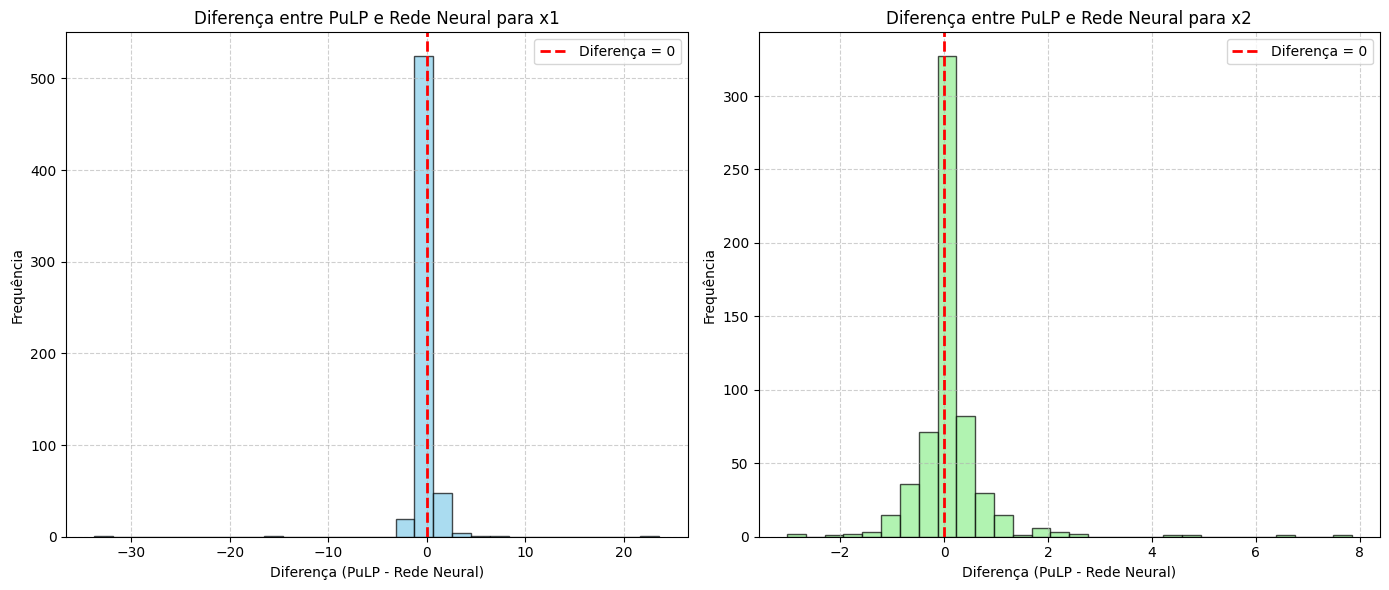

In [ ]:
from IPython.display import Image, display

print("\nHistograma da Diferença (PuLP - Rede Neural)")
display(Image('res_hist.png'))

---

Para verificar a significância estatística da diferença entre as soluções da rede neural e as soluções ótimas do PuLP, um novo conjunto de 600 problemas foi gerado para teste. O Teste de Wilcoxon foi aplicado para cada variável de decisão ($x_1$ e $x_2$), comparando os resultados obtidos pela rede neural com os do PuLP.

* **Variável $x_1$**: O p-valor de **0.1317** (maior que $\alpha=0.05$) indica que a diferença nas soluções para a variável $x_1$ não é estatisticamente significativa.
* **Variável $x_2$**: O p-valor de **0.4346** (maior que $\alpha=0.05$) indica que a diferença nas soluções para a variável $x_2$ não é estatisticamente significativa.

O resultado do Teste de Wilcoxon sugere que as soluções previstas pela rede neural são, do ponto de vista estatístico, indistinguíveis das soluções ótimas fornecidas pelo PuLP.

---

## Análise Visual e Intervalos de Confiança

* **Histogramas de Diferença**: A maioria das diferenças entre as soluções está próxima de zero, indicando que a rede neural está gerando previsões extremamente próximas das soluções ótimas do PuLP. A distribuição das diferenças é aproximadamente simétrica em torno do zero, confirmando que a rede neural não tem um "viés" consistente de subestimar ou superestimar os valores.

Para complementar a análise, foram calculados os IC's de 95% para a diferença entre as soluções.

* **Diferença para $x_1$**: [-0.1896, 0.1184]
* **Diferença para $x_2$**: [0.0155, 0.1321]

O intervalo de confiança para $x_1$ contém zero, o que reforça a conclusão do Teste de Wilcoxon de que não há uma diferença estatisticamente significativa. Para $x_2$, o intervalo não contém zero, o que pode sugerir uma leve tendência. No entanto, o p-valor do teste de Wilcoxon, que é mais robusto para a distribuição dos dados, sugere que essa diferença não é estatisticamente forte o suficiente para ser considerada significativa.

---

# 5. Conclusões e Discussões

Foi construída uma rede neural treinada para aproximar a solução ótima de problemas de Programação Linear de pequena escala.

   - A rede neural, embora não seja um "solucionador exato", alcançou uma precisão notável, com métricas de erro baixas.

   - A análise estatística rigorosa mostrou que as soluções da rede neural não são estatisticamente diferentes das soluções exatas fornecidas pelo PuLP. Isso valida a abordagem da rede neural como um método viável e confiável.

   - A principal vantagem desta abordagem reside na velocidade de inferência. Uma vez treinada, a rede neural pode prever a solução em milissegundos, um custo computacional significativamente menor do que a execução de um solver de PL.

A principal limitação deste estudo é que ele foi conduzido com dados sintéticos e um tipo de problema de PL muito específico (duas variáveis e duas restrições). O próximo passo seria testar o modelo com problemas de maior dimensão e de fontes de dados reais para avaliar sua escalabilidade e generalização.
